In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

%matplotlib inline

In [42]:
df=pd.read_csv('TRAIN.csv')

In [43]:
df.head()

,F01,F02,F03,F04,F05,F06,F07,F08,F09,F10,...,F39,F40,F41,F42,F43,F44,F45,F46,F47,Class
0,0.185570,0.004568,0.005362,0.003335,0.005415,0.004895,0.012764,0.120138,0.140450,3.361753,...,0.041526,-0.230857,0.003310,0.042250,0.005975,0.002104,0.013878,0.001518,0.011347,0
1,0.369536,0.003983,0.003386,0.004902,0.007570,0.012136,0.118050,0.323925,0.132093,2.766117,...,-0.141285,-6.222857,0.834177,0.227968,0.018463,-0.020487,0.001246,0.007489,0.008724,1
2,0.602510,0.008442,0.012961,0.012870,0.046885,0.115401,0.065688,0.306677,0.498805,4.521201,...,0.011334,10.335251,-0.276614,-0.198900,-0.012756,0.014286,-0.001866,0.002687,0.013452,1
3,0.347957,0.064721,0.013611,0.011541,0.006492,0.008690,0.013192,0.164553,0.298665,3.170847,...,0.190479,2.864912,-1.921939,0.891690,1.108098,0.635431,0.081368,-0.000225,0.009166,0
4,0.233653,0.012217,0.010088,0.022095,0.026040,0.015062,0.016063,0.084648,0.213367,8.150943,...,0.203164,0.001812,-0.092731,0.005280,-0.213985,0.032195,0.002081,0.028930,-0.025912,1


In [44]:
df.columns

Index(['F01', 'F02', 'F03', 'F04', 'F05', 'F06', 'F07', 'F08', 'F09', 'F10',
       'F11', 'F12', 'F13', 'F14', 'F15', 'F16', 'F17', 'F18', 'F19', 'F20',
       'F21', 'F22', 'F23', 'F24', 'F25', 'F26', 'F27', 'F28', 'F29', 'F30',
       'F31', 'F32', 'F33', 'F34', 'F35', 'F36', 'F37', 'F38', 'F39', 'F40',
       'F41', 'F42', 'F43', 'F44', 'F45', 'F46', 'F47', 'Class'],
      dtype='object')

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43776 entries, 0 to 43775
Data columns (total 48 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   F01     43776 non-null  float64
 1   F02     43776 non-null  float64
 2   F03     43776 non-null  float64
 3   F04     43776 non-null  float64
 4   F05     43776 non-null  float64
 5   F06     43776 non-null  float64
 6   F07     43776 non-null  float64
 7   F08     43776 non-null  float64
 8   F09     43776 non-null  float64
 9   F10     43776 non-null  float64
 10  F11     43776 non-null  float64
 11  F12     43776 non-null  float64
 12  F13     43776 non-null  float64
 13  F14     43776 non-null  float64
 14  F15     43776 non-null  float64
 15  F16     43776 non-null  float64
 16  F17     43776 non-null  float64
 17  F18     43776 non-null  float64
 18  F19     43776 non-null  float64
 19  F20     43776 non-null  float64
 20  F21     43776 non-null  float64
 21  F22     43776 non-null  float64
 22

In [46]:
df.shape

(43776, 48)

### Data Cleaning

In [47]:
df.isnull().sum()

F01      0
F02      0
F03      0
F04      0
F05      0
F06      0
F07      0
F08      0
F09      0
F10      0
F11      0
F12      0
F13      0
F14      0
F15      0
F16      0
F17      0
F18      0
F19      0
F20      0
F21      0
F22      0
F23      0
F24      0
F25      0
F26      0
F27      0
F28      0
F29      0
F30      0
F31      0
F32      0
F33      0
F34      0
F35      0
F36      0
F37      0
F38      0
F39      0
F40      0
F41      0
F42      0
F43      0
F44      0
F45      0
F46      0
F47      0
Class    0
dtype: int64

In [48]:
# checking duplicated
df.duplicated().sum()

np.int64(738)

In [49]:
# removing duplicated
df.drop_duplicates(inplace=True)

In [50]:
df['Class'].value_counts()

Class
0    25727
1    17311
Name: count, dtype: int64

### Feature Selection

In [55]:
X=df.drop("Class", axis=1)
y=df['Class']

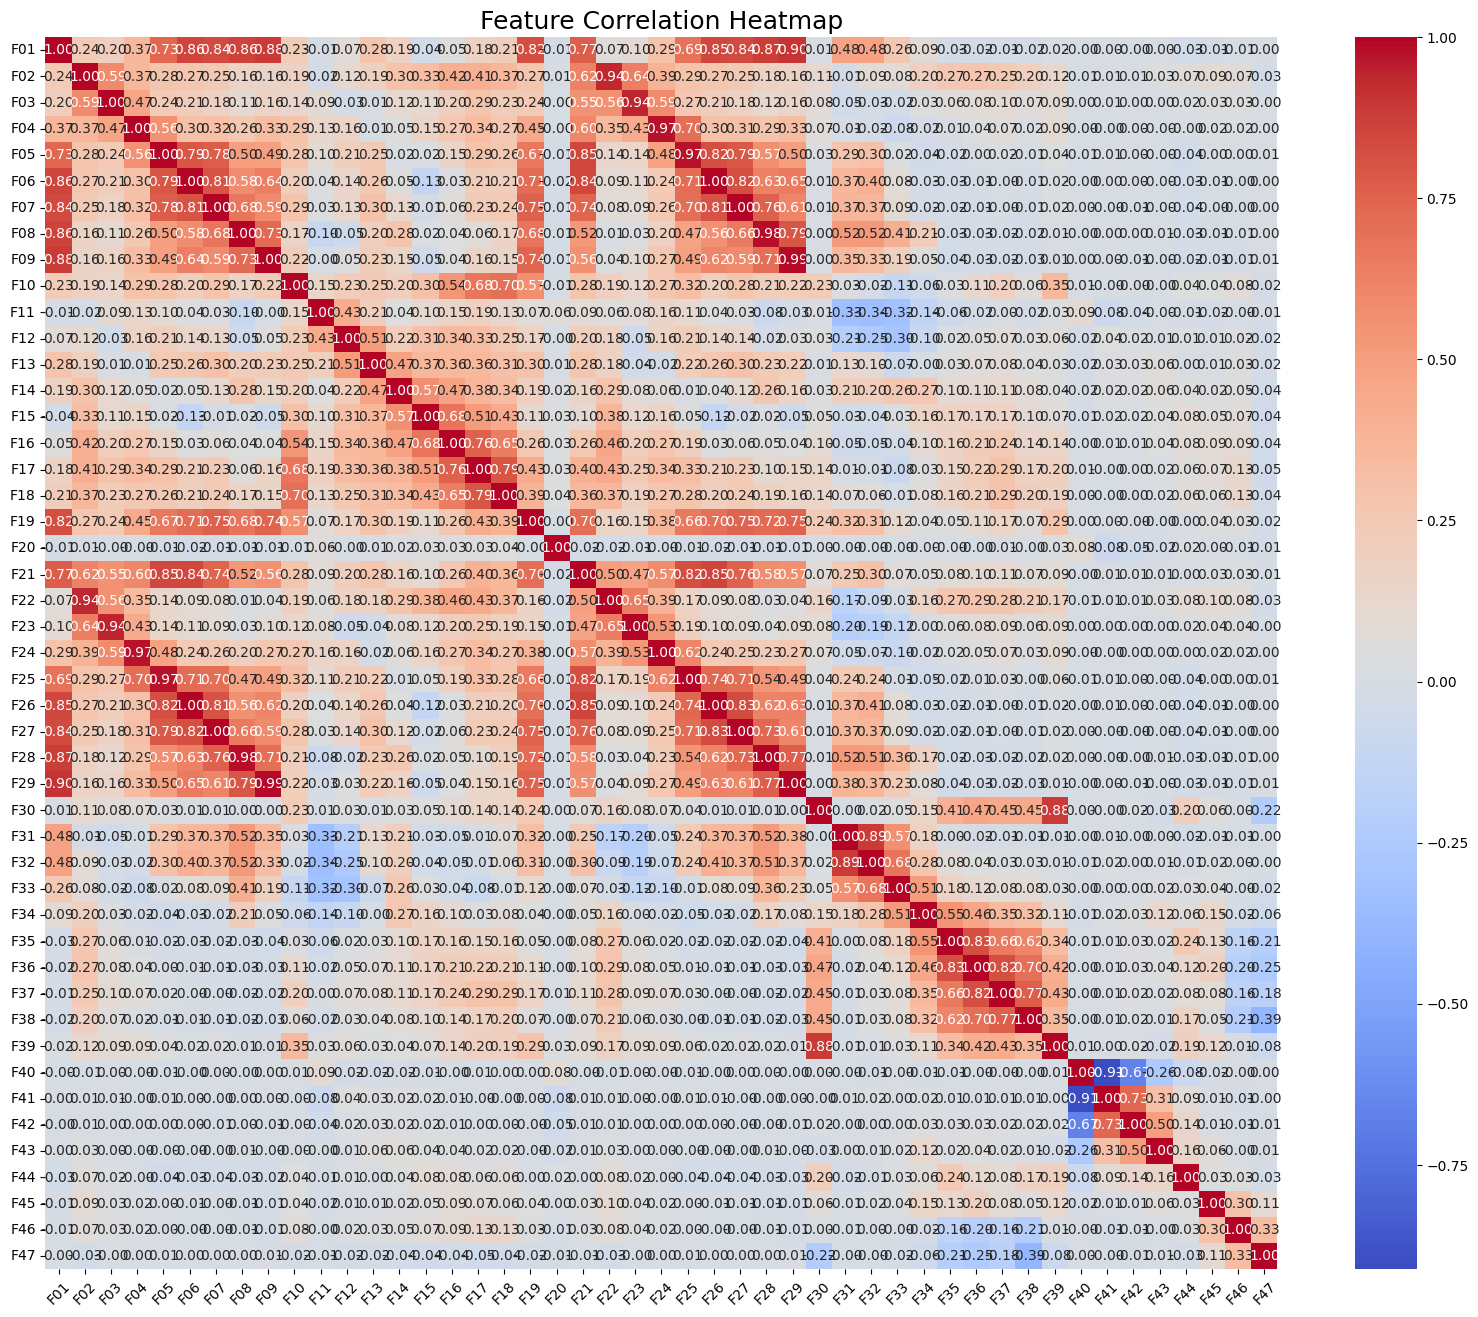

In [58]:
plt.figure(figsize=(20, 16))
sns.heatmap(X.corr(), annot=True, fmt=".2f", cmap="coolwarm", square=True)

plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.title("Feature Correlation Heatmap", fontsize=18)
plt.show()

In [59]:
cols=X.columns
cols

Index(['F01', 'F02', 'F03', 'F04', 'F05', 'F06', 'F07', 'F08', 'F09', 'F10',
       'F11', 'F12', 'F13', 'F14', 'F15', 'F16', 'F17', 'F18', 'F19', 'F20',
       'F21', 'F22', 'F23', 'F24', 'F25', 'F26', 'F27', 'F28', 'F29', 'F30',
       'F31', 'F32', 'F33', 'F34', 'F35', 'F36', 'F37', 'F38', 'F39', 'F40',
       'F41', 'F42', 'F43', 'F44', 'F45', 'F46', 'F47'],
      dtype='object')

In [60]:
corr_matrix = df[cols].corr().abs()
corr_matrix

,F01,F02,F03,F04,F05,F06,F07,F08,F09,F10,...,F38,F39,F40,F41,F42,F43,F44,F45,F46,F47
F01,1.000000,0.239973,0.202540,0.365491,0.733115,0.855055,0.839076,0.859153,0.880757,0.226998,...,0.016600,0.016373,0.002414,0.003589,0.002176,0.000101,0.032654,0.008826,0.007722,0.004459
F02,0.239973,1.000000,0.590426,0.366759,0.282244,0.269835,0.248217,0.157615,0.155464,0.185353,...,0.197188,0.124130,0.007139,0.011937,0.011710,0.030346,0.065224,0.091795,0.069599,0.034545
F03,0.202540,0.590426,1.000000,0.467449,0.240735,0.212192,0.180243,0.107619,0.157726,0.136301,...,0.065109,0.091686,0.003058,0.005818,0.001916,0.004874,0.019660,0.032494,0.031690,0.000517
F04,0.365491,0.366759,0.467449,1.000000,0.558588,0.302824,0.316037,0.259803,0.333768,0.294766,...,0.019773,0.092780,0.001807,0.000913,0.001378,0.001490,0.000157,0.015110,0.016298,0.000385
F05,0.733115,0.282244,0.240735,0.558588,1.000000,0.790912,0.775611,0.495793,0.487624,0.283626,...,0.005555,0.040870,0.006669,0.011405,0.004528,0.002974,0.042496,0.001037,0.001648,0.005557
F06,0.855055,0.269835,0.212192,0.302824,0.790912,1.000000,0.805149,0.576243,0.641243,0.204068,...,0.008539,0.019232,0.002071,0.004370,0.000070,0.002992,0.033297,0.007269,0.004960,0.004048
F07,0.839076,0.248217,0.180243,0.316037,0.775611,0.805149,1.000000,0.677320,0.592895,0.289075,...,0.008786,0.024835,0.001909,0.003161,0.006467,0.003478,0.037348,0.004209,0.003329,0.003807
F08,0.859153,0.157615,0.107619,0.259803,0.495793,0.576243,0.677320,1.000000,0.726485,0.169875,...,0.020826,0.010848,0.001640,0.001838,0.000887,0.006624,0.028146,0.010120,0.007923,0.001003
F09,0.880757,0.155464,0.157726,0.333768,0.487624,0.641243,0.592895,0.726485,1.000000,0.224182,...,0.025934,0.008672,0.000321,0.000760,0.008207,0.004639,0.024070,0.013274,0.011888,0.007631
F10,0.226998,0.185353,0.136301,0.294766,0.283626,0.204068,0.289075,0.169875,0.224182,1.000000,...,0.059141,0.354237,0.005763,0.002191,0.000588,0.000149,0.040575,0.041031,0.079478,0.020214


In [63]:
col_to_drop = set()  # this will help to store columns once only

for i in corr_matrix.columns:
    for j in corr_matrix.columns:
        if i!=j and corr_matrix.loc[i,j] > 0.85:
            col_to_drop.add(j)

In [64]:
selected_features = [f for f in cols if f not in col_to_drop]

print("Dropped features due to high correlation:", col_to_drop)
print("Remaining features:", selected_features)

Dropped features due to high correlation: {'F23', 'F24', 'F06', 'F26', 'F29', 'F05', 'F31', 'F04', 'F01', 'F30', 'F07', 'F09', 'F21', 'F32', 'F39', 'F08', 'F03', 'F41', 'F25', 'F27', 'F40', 'F28', 'F22', 'F02'}
Remaining features: ['F10', 'F11', 'F12', 'F13', 'F14', 'F15', 'F16', 'F17', 'F18', 'F19', 'F20', 'F33', 'F34', 'F35', 'F36', 'F37', 'F38', 'F42', 'F43', 'F44', 'F45', 'F46', 'F47']


In [65]:
# updating X
X=X[selected_features]

In [66]:
X

,F10,F11,F12,F13,F14,F15,F16,F17,F18,F19,...,F35,F36,F37,F38,F42,F43,F44,F45,F46,F47
0,3.361753,1.732333,2.937132,3.457153,3.641968,4.288155,4.417462,3.797210,3.789199,0.655360,...,3.508541,3.266424,3.044402,2.826142,0.042250,0.005975,0.002104,0.013878,0.001518,0.011347
1,2.766117,2.042004,3.218885,3.688284,4.187583,4.313245,3.143871,3.063356,3.616180,1.077621,...,4.246020,2.693811,2.333969,2.955462,0.227968,0.018463,-0.020487,0.001246,0.007489,0.008724
2,4.521201,1.619001,2.343310,2.792205,4.047557,4.337026,4.955743,4.763017,4.565633,3.330940,...,3.773208,4.373334,3.690733,3.423784,-0.198900,-0.012756,0.014286,-0.001866,0.002687,0.013452
3,3.170847,0.127451,0.959267,1.716752,2.476229,3.395086,4.336347,4.089776,2.961214,1.822241,...,133.213226,22.395124,3.194994,2.473058,0.891690,1.108098,0.635431,0.081368,-0.000225,0.009166
4,8.150943,2.389738,2.321244,2.521603,2.591896,3.765968,5.606859,6.754739,7.549006,2.024514,...,3.058993,5.351975,5.478570,7.595287,0.005280,-0.213985,0.032195,0.002081,0.028930,-0.025912
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43771,4.336341,2.266239,4.579189,3.280519,3.197178,3.225050,4.885856,4.759678,4.238292,5.620076,...,2.829746,4.259818,3.636931,3.272185,0.035450,0.001390,-0.003333,0.002385,0.001182,-0.010616
43772,3.395661,3.128596,2.466835,2.608767,2.662454,2.390591,3.226616,3.597718,3.680129,5.652178,...,2.054913,2.860337,2.941239,2.916853,0.373802,0.006406,-0.008244,-0.081317,-0.007015,-0.001864
43773,3.677857,2.146265,2.082369,2.648627,3.159841,3.464023,3.710605,4.169826,3.623933,2.007863,...,2.732907,2.988405,3.342886,2.750475,-0.012533,-0.034026,0.000177,0.005071,0.005763,0.005489
43774,2.097170,2.152998,2.932332,3.891911,4.103873,5.253971,4.036383,3.761275,2.158147,0.686159,...,3.394090,3.124155,3.118594,1.667138,-0.042303,0.037734,0.039146,-0.008112,-0.001419,0.000728


## Data Splitting

In [67]:
from sklearn.model_selection import train_test_split

In [68]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=42)

### Model Training

In [74]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, f1_score

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy of training:", accuracy_score(y_train, model.predict(X_train)))
print("Accuracy of testing:", accuracy_score(y_test, y_pred))
print("F1-Score:", f1_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy of training: 0.727046405098586
Accuracy of testing: 0.727772614622057
F1-Score: 0.5581395348837209
              precision    recall  f1-score   support

           0       0.71      0.93      0.80      7712
           1       0.81      0.43      0.56      5200

    accuracy                           0.73     12912
   macro avg       0.76      0.68      0.68     12912
weighted avg       0.75      0.73      0.70     12912



In [75]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score

rf = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("Accuracy of training:", accuracy_score(y_train, rf.predict(X_train)))
print("Accuracy of testing:", accuracy_score(y_test, y_pred))
print("F1-Score:", f1_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy of training: 1.0
Accuracy of testing: 0.9424566294919455
F1-Score: 0.9240984778833384
              precision    recall  f1-score   support

           0       0.92      0.99      0.95      7712
           1       0.99      0.87      0.92      5200

    accuracy                           0.94     12912
   macro avg       0.95      0.93      0.94     12912
weighted avg       0.95      0.94      0.94     12912



In [79]:
import xgboost as xgb
from sklearn.metrics import classification_report, accuracy_score, f1_score

xgb_model = xgb.XGBClassifier(
    eval_metric="auc",
    n_estimators=300,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=-1,
    random_state=42
)

xgb_model.fit(X_train, y_train)

y_pred = xgb_model.predict(X_test)

print("Accuracy of training:", accuracy_score(y_train, xgb_model.predict(X_train)))
print("Accuracy of testing:", accuracy_score(y_test, y_pred))
print("F1-Score:", f1_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy of training: 0.987751443935471
Accuracy of testing: 0.948729863692689
F1-Score: 0.9344034879112169
              precision    recall  f1-score   support

           0       0.94      0.98      0.96      7712
           1       0.96      0.91      0.93      5200

    accuracy                           0.95     12912
   macro avg       0.95      0.94      0.95     12912
weighted avg       0.95      0.95      0.95     12912



- so far xgboost is better is doing a hyperparameter tuning for xgboost

In [82]:
from sklearn.model_selection import RandomizedSearchCV
import xgboost as xgb

xgb_model = xgb.XGBClassifier(
    eval_metric="logloss",
    n_jobs=-1,
    random_state=42
)

param_dist = {
    "n_estimators": [200, 300, 400],
    "max_depth": [4, 5, 6],
    "learning_rate": [0.05, 0.1, 0.15],
    "subsample": [0.7, 0.8, 0.9],
    "colsample_bytree": [0.7, 0.8, 0.9]
}

xgb_search = RandomizedSearchCV(
    xgb_model,
    param_distributions=param_dist,
    n_iter=8,
    cv=3,
    scoring="f1",
    n_jobs=-1,
    random_state=42,
    verbose=1
)

xgb_search.fit(X_train, y_train)

best_xgb = xgb_search.best_estimator_

print("Best Parameters:", xgb_search.best_params_)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best Parameters: {'subsample': 0.8, 'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.15, 'colsample_bytree': 0.9}


In [83]:
y_pred = best_xgb.predict(X_test)

print("Accuracy of training:", accuracy_score(y_train, best_xgb.predict(X_train)))
print("Accuracy of testing:", accuracy_score(y_test, y_pred))
print("F1-Score:", f1_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy of training: 0.9979419770298081
Accuracy of testing: 0.9552354399008675
F1-Score: 0.9432108469247397
              precision    recall  f1-score   support

           0       0.95      0.98      0.96      7712
           1       0.96      0.92      0.94      5200

    accuracy                           0.96     12912
   macro avg       0.96      0.95      0.95     12912
weighted avg       0.96      0.96      0.96     12912



In [ ]:
# storing best_rf model in pkl file

import joblib
joblib.dump(best_xgb, "../models/best_model.pkl")

['models/best_model.pkl']

In [ ]:
joblib.dump(selected_features, "../models/columns.pkl")

['columns.pkl']

### TEST.csv
- checking if TEST.csv have any null value or not

In [88]:
df_test=pd.read_csv("TEST.csv")

In [89]:
df_test.isna().sum()

ID     0
F01    0
F02    0
F03    0
F04    0
F05    0
F06    0
F07    0
F08    0
F09    0
F10    0
F11    0
F12    0
F13    0
F14    0
F15    0
F16    0
F17    0
F18    0
F19    0
F20    0
F21    0
F22    0
F23    0
F24    0
F25    0
F26    0
F27    0
F28    0
F29    0
F30    0
F31    0
F32    0
F33    0
F34    0
F35    0
F36    0
F37    0
F38    0
F39    0
F40    0
F41    0
F42    0
F43    0
F44    0
F45    0
F46    0
F47    0
dtype: int64

so there is no null column in test.csv

In [90]:
df_test.shape

(10944, 48)

In [92]:
import joblib

columns=joblib.load("models/columns.pkl")
model=joblib.load("models/best_model.pkl")

In [98]:
X_df_test=df_test[columns]

In [99]:
y_test_pred=model.predict(X_df_test)

In [100]:
y_test_pred

array([1, 0, 1, ..., 1, 1, 1], shape=(10944,))

In [101]:
output_df = pd.DataFrame({
    'ID': df_test['ID'],
    'CLASS': y_test_pred
})

In [102]:
output_df.to_csv("FINAL.csv", index=False)